In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numba import njit
import seaborn as sns
import bayesflow as bf

import sys
sys.path.append("../")

from src.generative_models import *
from src.priors import pt_prior, mvl_prior

np.set_printoptions(suppress=True)

/Users/lschumacher/miniconda3/envs/beef/lib/python3.11/site-packages/bayesflow/trainers.py:27: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [2]:
NUM_SIM = 200
NUM_SAMPLES = 1000

AGENT_LABELS = [
    "Loss averse", "Var averse", "Both aversions", "No aversions",
]
DATA_TYPE = ["New Lotteries", "Old Lotteries"]

FONTSIZE_1 = 20
FONTSIZE_2 = 16
FONTSIZE_3 = 14

In [3]:
import matplotlib
matplotlib.rcParams['font.serif'] = "Palatino"
matplotlib.rcParams['font.family'] = "serif"

## Context

In [4]:
gamble_new = pd.read_csv('../data/three_outcome_lotteries_new.csv')
# gamble_new = gamble_new.loc[gamble_new.ev_diff == 0]
gamble_old = pd.read_csv('../data/three_outcome_lotteries_traditional.csv')
# gamble_old = gamble_old.loc[gamble_old.ev_diff == 0]

context_new = gamble_new[[
    'outcome_a1', 'outcome_a2', 'outcome_a3',
    'outcome_b1', 'outcome_b2', 'outcome_b3'
]].to_numpy()

context_old = gamble_old[[
    'outcome_a1', 'outcome_a2', 'outcome_a3',
    'outcome_b1', 'outcome_b2', 'outcome_b3'
]].to_numpy()

## Agents

In [5]:
tau = 5
b_weights = 0.5
alpha = 0.7
lamda = 2

theta_pt_la = np.array([lamda, 1, tau])
theta_pt_var = np.array([1, alpha, tau])
theta_pt_both = np.array([1.7, alpha, tau])
theta_pt_no = np.array([1, 1, tau])

theta_pt = [theta_pt_la, theta_pt_var, theta_pt_both, theta_pt_no]

theta_mvl_la = np.array([0, b_weights, tau])
theta_mvl_var = np.array([b_weights, 0, tau])
theta_mvl_both = np.array([b_weights, 0.3, tau])
theta_mvl_no = np.array([0, 0, tau])

theta_mvl = [theta_mvl_la, theta_mvl_var, theta_mvl_both, theta_mvl_no]

## Data Simulation

In [6]:
pt_agent_data = np.zeros((2, 4, NUM_SIM, context_new.shape[0], 7))
mvl_agent_data = np.zeros((2, 4, NUM_SIM, context_new.shape[0], 7))

In [50]:
trans_context_new = context_new / 50
trans_context_old = context_old / 50
for i in range(NUM_SIM):
    for j in range(4):
        pt_agent_data[0, j, i, :, 0] = sample_pt_model(theta_pt[j], context_new)
        pt_agent_data[0, j, i, :, 1:] = trans_context_new
        pt_agent_data[1, j, i, :, 0] = sample_pt_model(theta_pt[j], context_old)
        pt_agent_data[1, j, i, :, 1:] = trans_context_old
        mvl_agent_data[0, j, i, :, 0] = sample_mvl_model(theta_mvl[j], context_new)
        mvl_agent_data[0, j, i, :, 1:] = trans_context_new
        mvl_agent_data[1, j, i, :, 0] = sample_mvl_model(theta_mvl[j], context_old)
        mvl_agent_data[1, j, i, :, 1:] = trans_context_old

In [51]:
pt_agent_data_means = pt_agent_data[:, :, :, :, 0].mean(axis=3).mean(axis=2)
mvl_agent_data_means = mvl_agent_data[:, :, :, :, 0].mean(axis=3).mean(axis=2)
pt_agent_data_stds = pt_agent_data[:, :, :, :, 0].mean(axis=3).std(axis=2)
mvl_agent_data_stds = mvl_agent_data[:, :, :, :, 0].mean(axis=3).std(axis=2)

means = [pt_agent_data_means, mvl_agent_data_means]
stds = [pt_agent_data_stds, mvl_agent_data_stds]

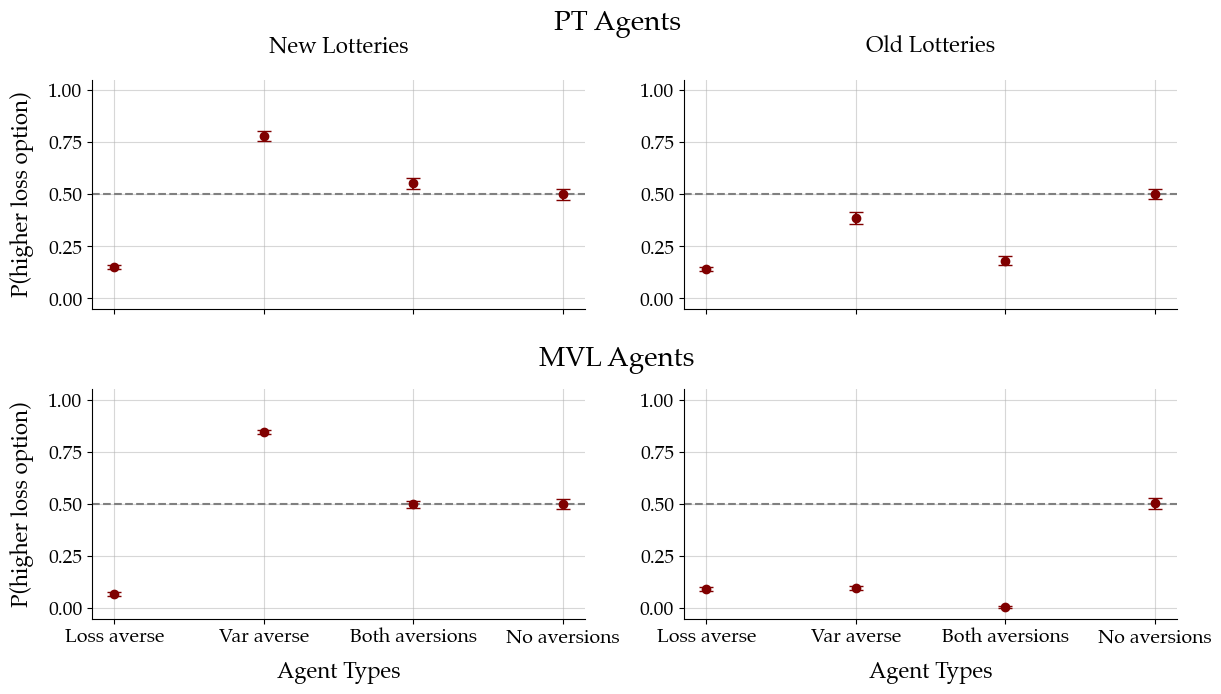

In [52]:
fig, axrr = plt.subplots(2, 2, figsize=(14, 7))
fig.text(0.5, 0.96, 'PT Agents', ha='center', va='center', fontsize=FONTSIZE_1)
fig.text(0.5, 0.48, 'MVL Agents', ha='center', va='center', fontsize=FONTSIZE_1)

for i, ax in enumerate(axrr.flat):
    if i < 2:
        for j in range(4):
            ax.errorbar(
                AGENT_LABELS[j], 1 - means[0][i, j],
                yerr=stds[0][i, j], fmt='o', capsize=5,
                color='maroon', ecolor='maroon'
            )
        ax.set_xticklabels([])
        ax.set_title(DATA_TYPE[i], fontsize=FONTSIZE_2, pad=20)
    if i >= 2:
        for j in range(4):
            ax.errorbar(
                AGENT_LABELS[j], 1 - means[1][i - 2, j],
                yerr=stds[1][i - 2, j], fmt='o', capsize=5,
                color='maroon', ecolor='maroon'
            )
        ax.set_xlabel("Agent Types", fontsize=FONTSIZE_2, labelpad=10)
    if i == 0 or i == 2:
        ax.set_ylabel("P(higher loss option)", fontsize=FONTSIZE_2, labelpad=10)
    ax.tick_params(axis='both', which='major', labelsize=FONTSIZE_3)
    ax.set_ylim(-0.05, 1.05)
    ax.axhline(y=0.5, linestyle='--', color='gray', linewidth=1.5)
    ax.grid(alpha=0.5)

sns.despine()
plt.subplots_adjust(hspace=0.35)
plt.savefig("../plots/agent_simulation_summary.pdf", dpi=300, bbox_inches="tight")

## Data Fitting

In [53]:
summary_net = bf.networks.SetTransformer(input_dim=7, summary_dim=32)

inference_net = bf.networks.InvertibleNetwork(
    num_params=len(pt_prior.param_names),
    coupling_settings={"dense_args": dict(kernel_regularizer=None), "dropout": False},
)

In [54]:
pt_amortizer = bf.amortizers.AmortizedPosterior(inference_net, summary_net)
mvl_amortizer = bf.amortizers.AmortizedPosterior(inference_net, summary_net)

In [55]:
pt_trainer = bf.trainers.Trainer(
    generative_model=pt_model, 
    amortizer=pt_amortizer, 
    configurator=pt_configurator, 
    checkpoint_path=f"../checkpoints/pt_model_final",
    max_to_keep=1
)

INFO:root:Loaded loss history from ../checkpoints/pt_model_final/history_100.pkl.
INFO:root:Networks loaded from ../checkpoints/pt_model_final/ckpt-100
INFO:root:Performing a consistency check with provided components...
INFO:root:Done.


In [56]:
# mvl_model(32)

In [57]:
# mvl_trainer = bf.trainers.Trainer(
#     generative_model=mvl_model, 
#     amortizer=mvl_amortizer, 
#     configurator=mvl_configurator, 
#     checkpoint_path=f"../checkpoints/{mvl_model.name}",
#     max_to_keep=1
# )

In [58]:
pt_post_z = np.zeros((2, 4, NUM_SIM, NUM_SAMPLES, 3))
mvl_post_z = np.zeros((2, 4, NUM_SIM, NUM_SAMPLES, 3))

In [59]:
for idx in np.ndindex(pt_post_z.shape[:2]):
    i, j = idx
    pt_post_z[i, j] = pt_amortizer.sample(
        {"summary_conditions": pt_agent_data[i, j].astype(np.float32)},
        NUM_SAMPLES
    )
    # mvl_post_z[i, j] = np.random.rand(context_new.shape[0], NUM_SAMPLES, 3)

In [60]:
pt_post = pt_post_z * PT_PRIOR_STD + PT_PRIOR_MEAN

In [61]:
pt_post_median = np.median(pt_post, axis=3)

In [62]:
def get_rmse(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mse = np.mean((y_true - y_pred) ** 2, axis=0)
    rmse = np.sqrt(mse)
    return rmse

In [63]:
pt_rmses = np.zeros((2, 4, 3))
for idx in np.ndindex(pt_post_median.shape[:2]):
    i, j = idx
    pt_rmses[i, j] = get_rmse(theta_pt[j], pt_post_median[i, j])

In [71]:
pt_rmses.shape

(2, 4, 3)

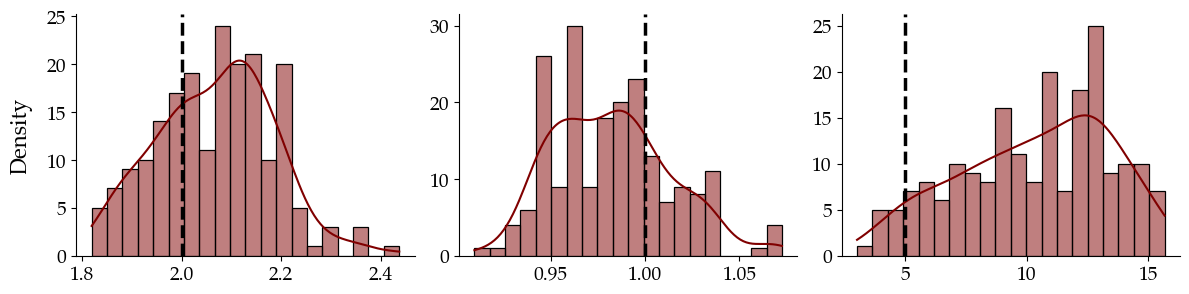

In [72]:
fig = plt.figure(figsize=(12, 3))
axs = fig.subplots(nrows=1, ncols=3)
for i, ax in enumerate(axs):
    sns.histplot(pt_post_median[0, 0, :, i], ax=ax, color='maroon', kde=True, bins=20)
    ax.axvline(x=theta_pt[0][i], linestyle='--', color='black', linewidth=2.5)
    # ax.set_title(param_names[i], fontsize=FONTSIZE_1)
    ax.tick_params(axis='both', which='major', labelsize=FONTSIZE_3)
    if i == 0:
        ax.set_ylabel("Density", fontsize=FONTSIZE_2, labelpad=10)
    else:
        ax.set_ylabel("")
sns.despine()
plt.tight_layout()

In [49]:
test_data = np.zeros((120, 7))
test_data[:, 0] = sample_pt_model(theta_pt[j], context_new)
test_data[:, 1:] = trans_context_new

In [43]:
theta_pt_la

array([2, 1, 5])

In [45]:
gamble_new

,outcome_a1,outcome_a2,outcome_a3,outcome_b1,outcome_b2,outcome_b3,ev_a,ev_b,ev_diff,var_a,var_b,var_diff,loss_a,loss_b,loss_diff,skew_a,skew_b,skew_diff
0,56,47,-38,96,8,-27,21.666667,25.666667,-4.0,42.350390,51.745102,-9.394711,-38,-27,-11,-0.68,0.47,-1.15
1,39,22,-9,62,3,-1,17.333333,21.333333,-4.0,19.871811,28.802006,-8.930195,-9,-1,-8,-0.34,0.70,-1.04
2,70,19,-62,87,3,-51,9.000000,13.000000,-4.0,54.350713,56.780278,-2.429565,-62,-51,-11,-0.27,0.26,-0.53
3,72,24,-48,97,1,-38,16.000000,20.000000,-4.0,49.315312,56.727418,-7.412106,-48,-38,-10,-0.24,0.46,-0.70
4,61,42,-33,89,13,-20,23.333333,27.333333,-4.0,40.581879,45.638678,-5.056799,-33,-20,-13,-0.59,0.44,-1.03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,82,59,-11,99,25,-6,43.333333,39.333333,4.0,39.550249,44.047954,-4.497704,-11,-6,-5,-0.53,0.45,-0.98
116,67,43,-36,85,3,-26,24.666667,20.666667,4.0,44.002525,47.005910,-3.003385,-36,-26,-10,-0.55,0.51,-1.06
117,63,61,-33,92,7,-20,30.333333,26.333333,4.0,44.790872,47.723742,-2.932870,-33,-20,-13,-0.71,0.54,-1.25
118,61,40,-11,79,4,-5,30.000000,26.000000,4.0,30.232433,37.656341,-7.423908,-11,-5,-6,-0.46,0.68,-1.14
